In [1]:
# 1. Import necessary libraries
import os
from dotenv import load_dotenv
from snowflake.snowpark import Session
import pandas as pd
from sklearn.preprocessing import RobustScaler

# 2. Load credentials from your .env file
load_dotenv()

connection_parameters = {
    "account": os.getenv("SNOWFLAKE_ACCOUNT"),
    "user": os.getenv("SNOWFLAKE_USER"),
    "password": os.getenv("SNOWFLAKE_PASSWORD"),
    "role": os.getenv("SNOWFLAKE_ROLE"),
    "warehouse": os.getenv("SNOWFLAKE_WAREHOUSE"),
    "database": os.getenv("SNOWFLAKE_DATABASE"),
    "schema": os.getenv("SNOWFLAKE_SCHEMA")
}

# 3. Create a Snowflake Session
session = Session.builder.configs(connection_parameters).create()
print(f"Connected to: {session.get_current_database()}.{session.get_current_schema()}")

# 4. Pull the data into a Pandas DataFrame
# We use .to_pandas() to bring the data from Snowflake into your computer's memory
df = session.table("RAW.TRANSACTIONS").to_pandas()

# 5. Scaling 'Amount' and 'Time'
# We use RobustScaler because it handles outliers better (common in fraud)
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['AMOUNT'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['TIME'].values.reshape(-1,1))

# Remove the old unscaled columns
df.drop(['TIME', 'AMOUNT'], axis=1, inplace=True)

# Move scaled columns to the front for better visibility
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

# 6. Preview the result
print("Data Scaled Successfully!")
df.head(10)



Connected to: "FRAUD_DETECTION_DB"."RAW"
Data Scaled Successfully!


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,CLASS
0,-0.196046,-0.566008,1.258270,0.059820,0.418057,0.768841,-0.313122,-0.298726,-0.072501,-0.127925,...,-0.042942,-0.109245,-0.018016,-0.163248,-0.026602,0.684650,0.465946,-0.010366,0.008094,0
1,8.406344,-0.565961,-1.108166,-1.361369,0.635896,1.913083,-1.502791,0.977664,-0.691483,-2.531040,...,1.845568,-0.905157,0.239620,-0.676265,0.382173,0.860989,-0.202224,-0.075524,0.224897,0
2,1.369384,-0.565925,1.188901,-1.651531,1.229683,-1.090734,-2.255480,-0.107147,-1.504465,0.115214,...,-0.098151,-0.109533,-0.010475,-0.017848,0.549223,0.160614,-0.237951,0.057086,0.043730,0
3,-0.044575,-0.565914,-1.312332,1.069948,2.520263,1.690548,-0.204190,-0.216563,0.230077,0.105047,...,-0.228809,0.078500,0.359803,-0.415762,0.733112,0.570780,0.032601,-0.115324,0.017873,0
4,-0.083980,-0.565855,-4.796741,2.795970,1.520652,-0.266592,-1.822730,0.408467,-0.456434,0.188625,...,1.161940,-0.385873,0.033249,-0.137031,0.391881,0.800958,0.410078,-0.369937,0.490853,0
5,-0.028226,-0.565820,1.490643,-0.967068,-0.068338,-1.375665,-1.171349,-0.886026,-0.671914,-0.137630,...,-0.481119,-0.496452,-1.160191,0.200284,-0.025885,0.201727,-0.414485,0.006191,0.009189,0
6,1.074268,-0.565796,1.141685,-0.894042,-0.441474,-2.406380,-0.374398,-0.074326,-0.342587,0.105348,...,0.060968,0.242440,0.660617,-0.397474,-1.116610,0.783641,-0.541799,0.060534,0.012492,0
7,3.725424,-0.565784,-1.736163,-1.716993,2.585283,-1.464800,-0.560294,2.516941,-0.171285,0.786942,...,0.885495,0.418660,1.148869,0.480802,-1.002299,0.284188,-0.111081,0.120393,-0.087850,0
8,-0.146859,-0.565749,1.231981,-0.434431,-0.353170,-0.312604,1.433196,3.956624,-1.201933,1.071646,...,0.028815,-0.143441,-0.376041,-0.006568,1.039654,0.413013,0.331773,0.018793,0.020933,0
9,-0.282401,-0.565702,1.213307,0.277917,0.318310,0.580329,-0.344206,-0.755309,-0.040387,-0.036349,...,-0.092368,-0.240169,-0.747081,0.120842,0.279459,0.174310,0.078312,-0.029221,0.019855,0


In [2]:
# Check the number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# If duplicates exist, show a few of them to understand the pattern
if duplicate_count > 0:
    print("\nSample of duplicated rows:")
    display(df[df.duplicated(keep=False)].head(6))

Number of duplicate rows found: 1081

Sample of duplicated rows:


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,CLASS
10,-0.184308,-0.565679,-7.240697,4.929300,-2.065604,0.430243,-1.855755,-0.261734,-0.579035,0.925849,...,1.144012,-0.275889,-0.154607,0.140556,0.016743,0.527471,-0.411761,-1.215463,0.999929,0
589,0.097813,-0.544837,1.206824,-0.051713,0.255879,-0.097189,-0.396809,-0.709528,0.013892,-0.123532,...,-0.044638,-0.186596,-0.556043,0.116790,0.132836,0.091903,0.873325,-0.075198,0.005604,0
604,0.866345,-0.544332,1.159396,-0.805808,0.904888,-0.385175,-1.366925,-0.519854,-0.691914,-0.087141,...,0.238229,0.286251,0.799671,-0.055733,0.679782,0.376851,-0.156100,0.038424,0.036264,0
826,-0.027947,-0.536660,-2.733661,2.254435,0.868432,1.732709,-2.007792,0.347186,-1.299968,2.058710,...,0.092964,-0.261592,-0.424688,0.184933,0.620555,0.151530,-0.383332,0.288451,0.094300,0
864,1.788584,-0.535286,-4.362234,2.459614,-1.219354,1.353313,-2.876045,-0.362284,-1.230696,2.393825,...,-0.469374,0.141001,0.011870,-0.364585,0.568891,-0.227361,-0.442784,-0.280095,-0.271852,0
910,-0.125480,-0.533629,-6.824932,4.730961,-1.135870,-1.147540,-1.204491,-0.495712,0.406601,0.154644,...,2.438122,-0.911861,-0.739516,0.322068,-0.012147,1.064169,0.312305,1.811306,2.067257,0


In [3]:
# Remove duplicates and keep only the first occurrence
df.drop_duplicates(inplace=True)

# Verify the new shape
print(f"New shape after removing duplicates: {df.shape}")

New shape after removing duplicates: (283726, 31)


In [4]:
# Define the new table name for your Silver layer
target_table = "TRANSACTIONS_CLEANED"

# Upload the DataFrame to the STG schema
# auto_create_table=True will build the table structure for you based on the df
session.write_pandas(
    df=df, 
    table_name=target_table, 
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema="STG", 
    auto_create_table=True,
    overwrite=True
)

print(f"Successfully uploaded {len(df)} rows to STG.{target_table}")

c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\snowflake\snowpark\session.py:3478: UserWarning: Pandas Dataframe has non-standard index of type <class 'pandas.core.indexes.base.Index'> which will not be written. Consider changing the index to pd.RangeIndex(start=0,...,step=1) or call reset_index() to keep index as column(s)
  success, _, _, ci_output = write_pandas(


Successfully uploaded 283726 rows to STG.TRANSACTIONS_CLEANED


In [5]:
# 1. Separate the Fraud and Legitimate classes
fraud_df = df.loc[df['CLASS'] == 1]
legit_df = df.loc[df['CLASS'] == 0]

# 2. Randomly sample the legitimate transactions to match the number of fraud cases
# We use .sample() with a random_state for reproducibility
legit_sample = legit_df.sample(n=len(fraud_df), random_state=42)

# 3. Combine them into a new balanced DataFrame
balanced_df = pd.concat([fraud_df, legit_sample])

# 4. Shuffle the data so the model doesn't see all frauds followed by all legit
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Verify the new distribution
print("New Balanced Distribution:")
print(balanced_df['CLASS'].value_counts())

# 6. Preview the first few rows
balanced_df.head()

New Balanced Distribution:
CLASS
1    473
0    473
Name: count, dtype: int64


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,CLASS
0,-0.254454,-0.511942,-3.600544,4.519047,-6.340884,6.214767,-5.829558,-2.478095,-9.938412,2.830086,...,1.384743,2.263770,0.620749,-0.094069,0.536719,0.398142,0.008277,2.053524,0.835749,1
1,0.222595,0.108225,-11.320633,7.191950,-13.179083,9.099552,-10.094749,-2.440115,-14.184337,4.452503,...,-0.180935,1.082235,-0.350563,0.483044,0.661133,-0.396522,-0.413315,-0.997548,-0.235036,1
2,0.187103,0.553378,0.026834,1.385675,-1.499609,3.391149,3.338806,4.561059,0.565089,0.735301,...,0.016317,0.184808,0.573329,0.157159,0.716145,-1.181605,0.246499,-0.050587,0.251397,0
3,-0.275554,0.182462,-19.641857,14.706335,-22.801238,12.114672,-14.898113,0.840778,-28.011293,-11.919639,...,3.834649,-8.228874,3.318178,2.585212,0.195009,-1.194803,0.038423,-4.126746,-0.645329,1
4,-0.293440,-0.899940,-1.783229,3.402794,-3.822742,2.625368,-1.976415,-2.731689,-3.430559,1.413204,...,0.364089,0.454032,-0.577526,0.045967,0.461700,0.044146,0.305704,0.530981,0.243746,1


In [6]:
from sklearn.model_selection import train_test_split

# 1. Separate Features (X) from Labels (y)
X = balanced_df.drop('CLASS', axis=1)
y = balanced_df['CLASS']

# 2. Split into Training and Testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Verify the shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")

X_train shape: (756, 30)
X_test shape: (190, 30)
y_train distribution:
CLASS
0    388
1    368
Name: count, dtype: int64


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the model
# n_estimators=100 means we are building 100 individual decision trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model (The .fit method is where the math happens!)
model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test)

# 4. Evaluate the results
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[84  1]
 [11 94]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93        85
           1       0.99      0.90      0.94       105

    accuracy                           0.94       190
   macro avg       0.94      0.94      0.94       190
weighted avg       0.94      0.94      0.94       190



Model saved as fraud_detection_model.pkl


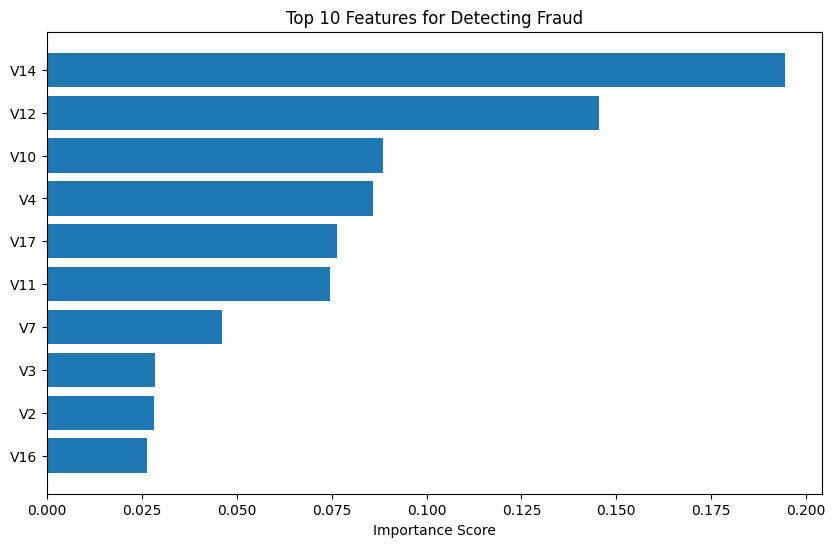

In [8]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# 1. Save the model to a file
joblib.dump(model, 'fraud_detection_model.pkl')
print("Model saved as fraud_detection_model.pkl")

# 2. Get Feature Importances
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Visualize the top 10 most important features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'].head(10), feature_importance_df['Importance'].head(10))
plt.xlabel('Importance Score')
plt.title('Top 10 Features for Detecting Fraud')
plt.gca().invert_yaxis()
plt.show()

In [11]:
# 1. Create a results DataFrame
results_df = X_test.copy()
results_df['ACTUAL_CLASS'] = y_test
results_df['PREDICTED_CLASS'] = y_pred

# FIX: Force all column names to uppercase to match Snowflake standards
results_df.columns = [col.upper() for col in results_df.columns]

# 2. Upload to Snowflake GOLD schema
session.write_pandas(
    df=results_df, 
    table_name="FINAL_FRAUD_PREDICTIONS", 
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema="GOLD", 
    auto_create_table=True,
    overwrite=True,
    quote_identifiers=False # This helps avoid naming conflicts
)

print("Project Complete! Your Gold-layer predictions are now live in Snowflake.")

c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\snowflake\snowpark\session.py:3478: UserWarning: Pandas Dataframe has non-standard index of type <class 'pandas.core.indexes.base.Index'> which will not be written. Consider changing the index to pd.RangeIndex(start=0,...,step=1) or call reset_index() to keep index as column(s)
  success, _, _, ci_output = write_pandas(


Project Complete! Your Gold-layer predictions are now live in Snowflake.
